In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [3]:
np.random.seed(42)
data = pd.DataFrame({
    "hours_studied": np.random.randint(1,10,50),
    "attendance":np.random.randint(50,100,50),
})
data.head()

,hours_studied,attendance
0,7,53
1,4,51
2,8,55
3,5,91
4,7,53


In [10]:
x = data[['hours_studied', 'attendance']]

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
data['cluster'] = kmeans.fit_predict(x)

score = silhouette_score(x, data["cluster"])
print("Silhouette Score:", score)

Silhouette Score: 0.5279952360324802


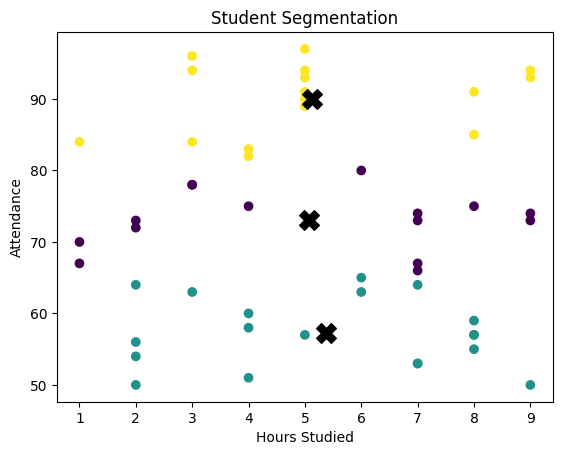

In [11]:
plt.scatter(data['hours_studied'], data['attendance'], c=data['cluster'])
centres = kmeans.cluster_centers_
plt.scatter(centres[:,0], centres[:,1], c='black', marker='X', s=200)
plt.xlabel("Hours Studied")
plt.ylabel("Attendance")
plt.title("Student Segmentation")
plt.show()

In [14]:
new_student = [[6,80]]
predicted_cluster = kmeans.predict(new_student)
print("New Student belongs to Cluster:", predicted_cluster[0])

New Student belongs to Cluster: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [15]:
data.groupby('cluster').mean()

,hours_studied,attendance
cluster,,
0,5.066667,73.000000
1,5.368421,57.315789
2,5.125000,90.000000
